# 가우시안 나이브베이즈 분류 모델

In [42]:
import numpy as np
import pandas as pd

from sklearn import set_config
set_config(display="text")

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn import metrics
from sklearn.metrics import accuracy_score

# 데이터 수집 및 특징 시각화

In [ ]:
# iris 데이터 불러움

dataset = load_iris()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head()  # dataset.data 훈련용 데이터

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [44]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [45]:
# 분류값을 데이터프레임에 저장
# target(종) : 정답 데이터
# petal(꽃잎), sepal(꽃받침)

df['target'] = dataset.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [46]:
# 전처리 작업
# 숫자인 분류값을 이해를 돕기위해 문자로 변경

df['target'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [47]:
df.target.value_counts()

target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### iris 데이터의 분포도 확인

In [48]:
# 분류값 별로 데이터프레임을 나눔
setosa_df = df[df.target == "setosa"]
versicolor_df = df[df.target == "versicolor"]
virginica_df = df[df.target == "virginica"]

## sepal length (cm)

<Axes: >

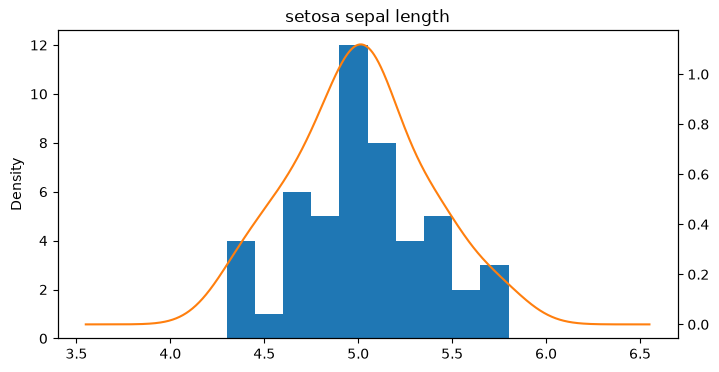

In [49]:
# setosa 종의 꽃받침(sepal)의 길이
ax = setosa_df['sepal length (cm)'].plot(kind='hist')
setosa_df['sepal length (cm)'].plot(kind='kde', # 커널 밀도 추정(KDE: Kernel Density Estimator)
                                    ax=ax, 
                                    secondary_y=True, # 보조축 레이블을 출력할지 여부 
                                    title="setosa sepal length", 
                                    figsize = (8,4))

# 데이터는 정규 분포(가우시안 분포)특성을 가짐

<Axes: >

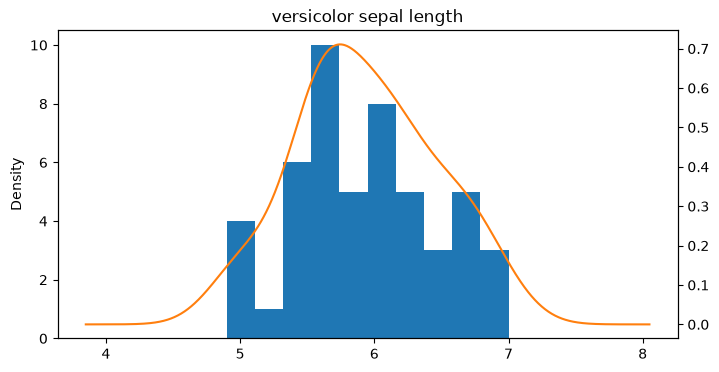

In [50]:
# versicolor 종의 꽃받침(sepal)의 길이

ax = versicolor_df['sepal length (cm)'].plot(kind='hist')
versicolor_df['sepal length (cm)'].plot(kind='kde', 
                                        ax=ax, 
                                        secondary_y=True, 
                                        title="versicolor sepal length", 
                                        figsize = (8,4))

<Axes: >

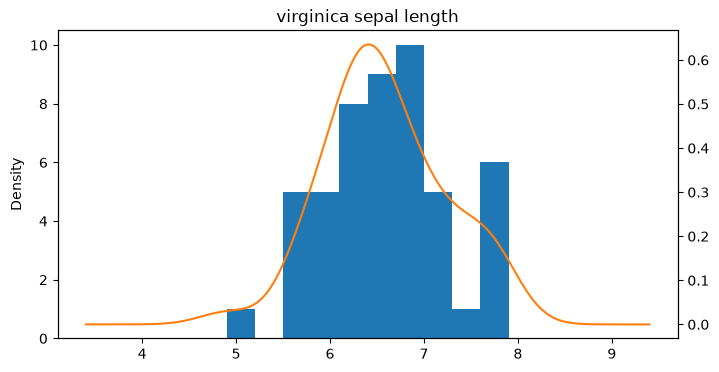

In [51]:
# virginica 종의 꽃받침(sepal)의 길이

ax = virginica_df['sepal length (cm)'].plot(kind='hist')
virginica_df['sepal length (cm)'].plot(kind='kde', 
                                       ax=ax, 
                                       secondary_y=True, 
                                       title="virginica sepal length", 
                                       figsize = (8,4))

## sepal width (cm)	

<Axes: >

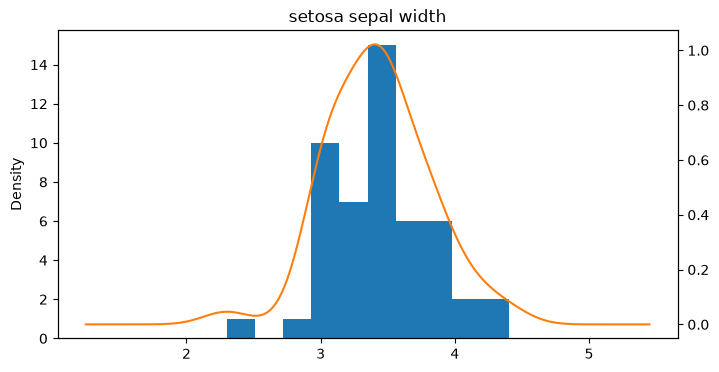

In [52]:
# setosa 종의 꽃받침(sepal)의 넓이

ax = setosa_df['sepal width (cm)'].plot(kind='hist')
setosa_df['sepal width (cm)'].plot(kind='kde', 
                                   ax=ax, 
                                   secondary_y=True, 
                                   title="setosa sepal width", 
                                   figsize = (8,4))

<Axes: >

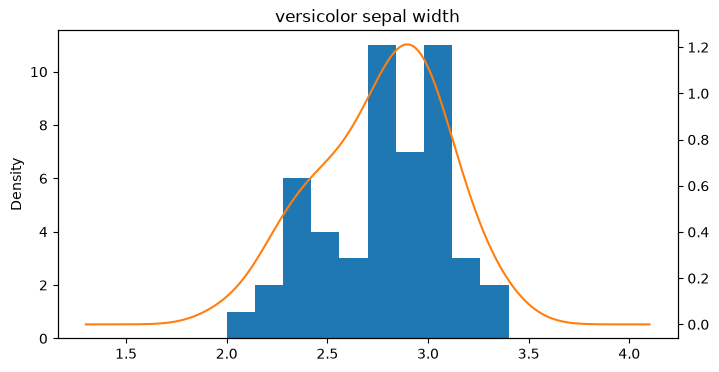

In [53]:
# versicolor 종의 꽃받침(sepal)의 넓이

ax = versicolor_df['sepal width (cm)'].plot(kind='hist')
versicolor_df['sepal width (cm)'].plot(kind='kde', 
                                       ax=ax, 
                                       secondary_y=True, 
                                       title="versicolor sepal width", 
                                       figsize = (8,4))

<Axes: >

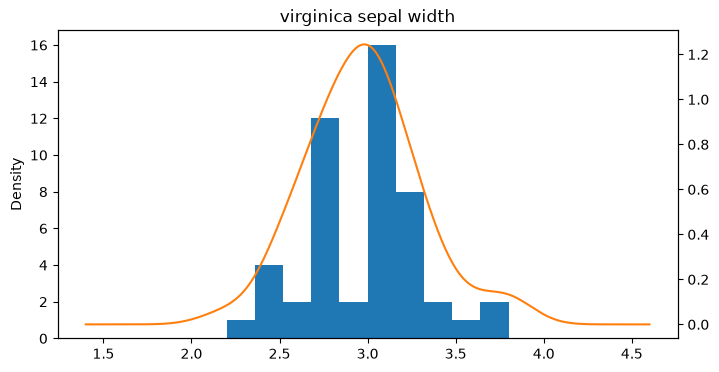

In [54]:
# virginica 종의 꽃받침(sepal)의 넓이

ax = virginica_df['sepal width (cm)'].plot(kind='hist')
virginica_df['sepal width (cm)'].plot(kind='kde', 
                                      ax=ax, 
                                      secondary_y=True, 
                                      title="virginica sepal width", 
                                      figsize = (8,4))

## petal length (cm)

<Axes: >

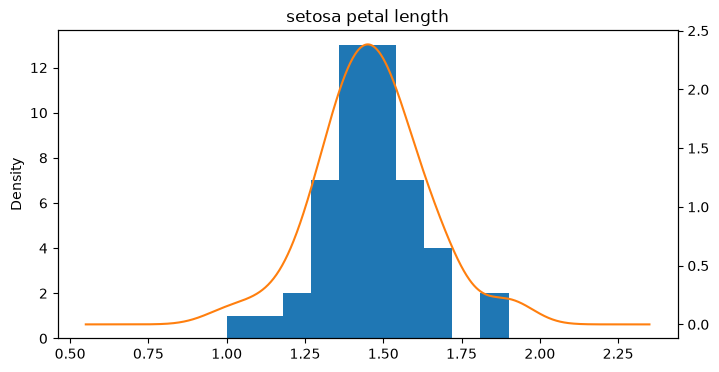

In [55]:
# setosa 종의 꽃잎(petal)의 넓이

ax = setosa_df['petal length (cm)'].plot(kind='hist')
setosa_df['petal length (cm)'].plot(kind='kde', 
                                    ax=ax, 
                                    secondary_y=True, 
                                    title="setosa petal length", 
                                    figsize = (8,4))

<Axes: >

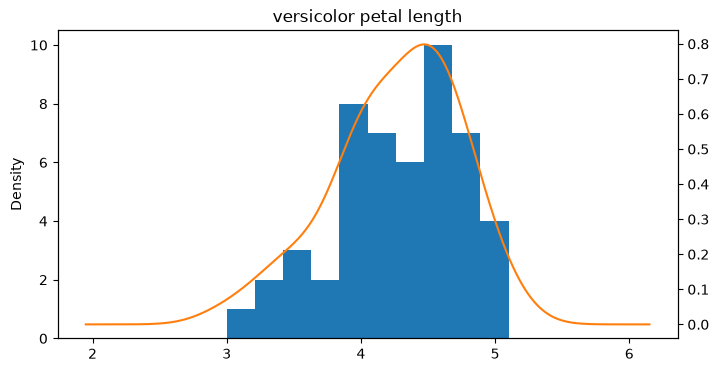

In [56]:
# versicolor 종의 꽃잎(petal)의 넓이

ax = versicolor_df['petal length (cm)'].plot(kind='hist')
versicolor_df['petal length (cm)'].plot(kind='kde', 
                                        ax=ax, 
                                        secondary_y=True, 
                                        title="versicolor petal length", 
                                        figsize = (8,4))

<Axes: >

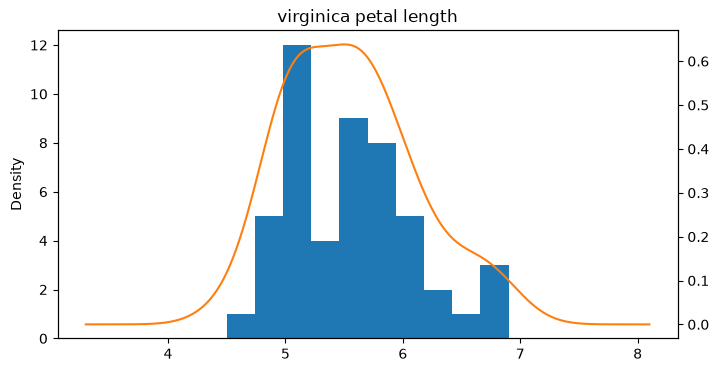

In [57]:
# virginica 종의 꽃잎(petal)의 넓이

ax = virginica_df['petal length (cm)'].plot(kind='hist')
virginica_df['petal length (cm)'].plot(kind='kde', 
                                       ax=ax, 
                                       secondary_y=True, 
                                       title="virginica petal length", 
                                       figsize = (8,4))

## petal width (cm)

<Axes: >

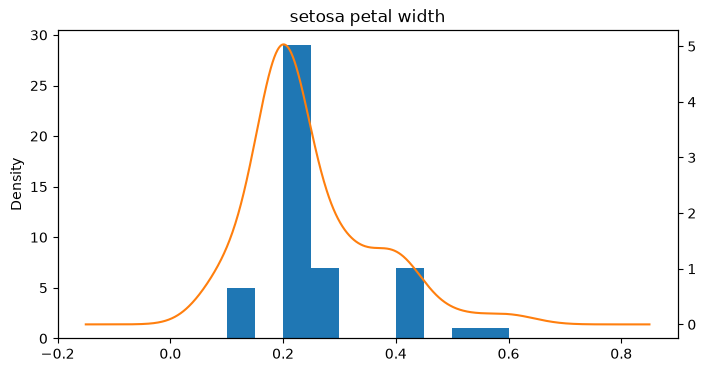

In [58]:
ax = setosa_df['petal width (cm)'].plot(kind='hist')
setosa_df['petal width (cm)'].plot(kind='kde', 
                                   ax=ax, 
                                   secondary_y=True, 
                                   title="setosa petal width", 
                                   figsize = (8,4))

<Axes: >

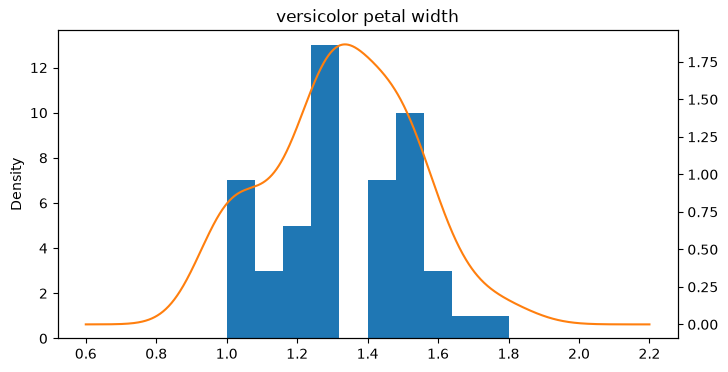

In [59]:
ax = versicolor_df['petal width (cm)'].plot(kind='hist')
versicolor_df['petal width (cm)'].plot(kind='kde', 
                                       ax=ax, 
                                       secondary_y=True, 
                                       title="versicolor petal width", 
                                       figsize = (8,4))

<Axes: >

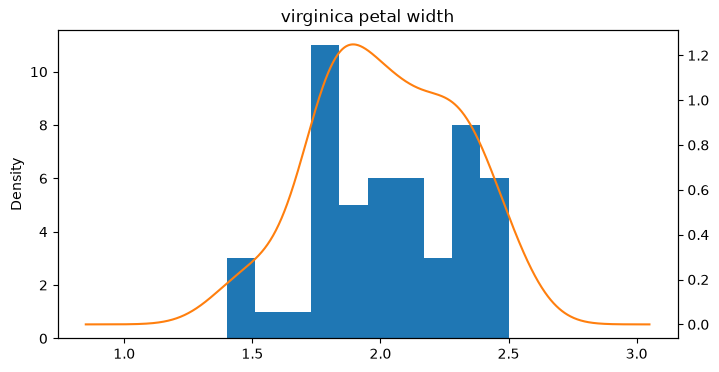

In [60]:
ax = virginica_df['petal width (cm)'].plot(kind='hist')
virginica_df['petal width (cm)'].plot(kind='kde', 
                                      ax=ax, 
                                      secondary_y=True, 
                                      title="virginica petal width", 
                                      figsize = (8,4))

### 데이터를 학습 데이터와 테스트 데이터로 나누기

In [61]:
# 20%를 테스트 데이터로 사용, test_size=0.2
# train_test_split() 함수 사용하면 학습 데이터와 테스트 데이터를 8:2로 분류해줌
# y_train 정답 데이터
# 학습 데이터, 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.2)  


## Gaussian Naive Bayes 분류하기

In [62]:
# 학습데이터로 모델을 학습
model = GaussianNB()

model.fit(X_train, y_train)  # 학습 해라!  X_train : 학습 데이터, y_train : 정답 데이터


GaussianNB()

In [63]:
# 테스트 데이터로 모델을 테스트
# predicted 모델이 예측한 데이터
predicted = model.predict(X_test) #  한번도 학습하지 않았던 X_test


In [64]:
# 성능지표 모델 metrics
print(metrics.classification_report(y_test, predicted))  # 분류 레포트 생성,  y_test(정답 데이터), predicted(예측 데이터)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.78      1.00      0.88         7
           2       1.00      0.87      0.93        15

    accuracy                           0.93        30
   macro avg       0.93      0.96      0.93        30
weighted avg       0.95      0.93      0.94        30



In [65]:
# y_test: 정답 데이터, predicted: 예측 데이터
accuracy_score(y_test, predicted) 

0.9333333333333333

## Confusion Matrix

In [66]:
print(metrics.confusion_matrix(y_test, predicted))

[[ 8  0  0]
 [ 0  7  0]
 [ 0  2 13]]
